In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import mmread
import warnings
warnings.filterwarnings('ignore')

out_dir = '/data1/project/yeonu/065_multi_rna/Deg_80/results_output'
data_dir = '/data1/project/yeonu/065_multi_rna/data'

In [2]:
# DEG 결과 로드 및 Top 10 Up + Top 10 Down 유전자 선택
deg = pd.read_csv(os.path.join(out_dir, 'MAST_DEGs_Cirrhosis_NTvsTC_Hepatocyte.csv'))
deg_sig = deg[(deg['padj'] < 0.05) & (deg['log2FC'].abs() >= 0.5)].copy()

top_up = deg_sig[deg_sig['log2FC'] > 0].nsmallest(10, 'pvalue')
top_down = deg_sig[deg_sig['log2FC'] < 0].nsmallest(10, 'pvalue')

print(f'Significant DEGs (padj<0.05, |log2FC|>=0.5): {len(deg_sig)}')
print(f'Top 10 Up-regulated genes: {list(top_up["gene"])}')
print(f'Top 10 Down-regulated genes: {list(top_down["gene"])}')

Significant DEGs (padj<0.05, |log2FC|>=0.5): 861
Top 10 Up-regulated genes: ['GLUL', 'PDK4', 'DCXR', 'PAGE4', 'FTH1', 'GAPDH', 'ATOX1', 'UQCRQ', 'RPL10', 'ROBO1']
Top 10 Down-regulated genes: ['APOA1', 'A2M', 'SLC7A2', 'SORL1', 'DPYD', 'UTY', 'GPC6', 'ST6GAL1', 'LPIN2', 'CP']


In [3]:
# Count matrix & metadata 로드
print('Loading count matrix...')
counts = mmread(os.path.join(data_dir, 'counts_sparse_80.mtx')).tocsc()
gene_meta = pd.read_csv(os.path.join(data_dir, 'gene_metadata_80.csv'))
cell_meta = pd.read_csv(os.path.join(data_dir, 'cell_metadata.csv'), low_memory=False)

gene_names = list(gene_meta['gene'])
print(f'Matrix shape: {counts.shape}')
print(f'Genes: {len(gene_names)}, Cells: {len(cell_meta)}')

Loading count matrix...
Matrix shape: (99541, 1341)
Genes: 1341, Cells: 99541


In [4]:
# Cirrhosis Hepatocyte만 추출 (NT vs TC)
mask = (cell_meta['status'] == 'Cirrhosis') & (cell_meta['predicted_celltype'] == 'Hepatocytes')
mask = mask & (cell_meta['group'].isin(['NT', 'TC']))
cell_idx = np.where(mask.values)[0]
groups = cell_meta.loc[mask, 'group'].values

print(f'Cirrhosis Hepatocytes: {len(cell_idx)}')
print(f'  NT: {(groups == "NT").sum()}, TC: {(groups == "TC").sum()}')

Cirrhosis Hepatocytes: 55682
  NT: 8167, TC: 47515


In [5]:
# 20개 유전자 발현량 추출 + log1p 정규화
target_genes = list(top_up['gene']) + list(top_down['gene'])
gene_indices = [gene_names.index(g) for g in target_genes]

expr_raw = counts[cell_idx][:, gene_indices].toarray()
expr_log = np.log1p(expr_raw)

expr_df = pd.DataFrame(expr_log, columns=target_genes)
expr_df['group'] = groups

print(f'Expression matrix: {expr_df.shape}')
expr_df.head()

Expression matrix: (55682, 21)


,GLUL,PDK4,DCXR,PAGE4,FTH1,GAPDH,ATOX1,UQCRQ,RPL10,ROBO1,...,A2M,SLC7A2,SORL1,DPYD,UTY,GPC6,ST6GAL1,LPIN2,CP,group
0,1.598332,0.0,0.0,0.0,0.886693,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.886693,0.000000,0.886693,0.000000,0.000000,0.000000,0.886693,TC
1,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,TC
2,1.353851,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.000000,0.902942,0.000000,0.000000,0.683726,0.000000,TC
3,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.000000,1.523246,0.000000,0.000000,0.000000,0.000000,0.000000,TC
4,1.520039,0.0,0.0,0.0,0.000000,0.0,0.832007,0.0,0.0,0.0,...,0.0,0.832007,0.000000,0.000000,0.000000,0.832007,0.832007,0.832007,0.000000,TC


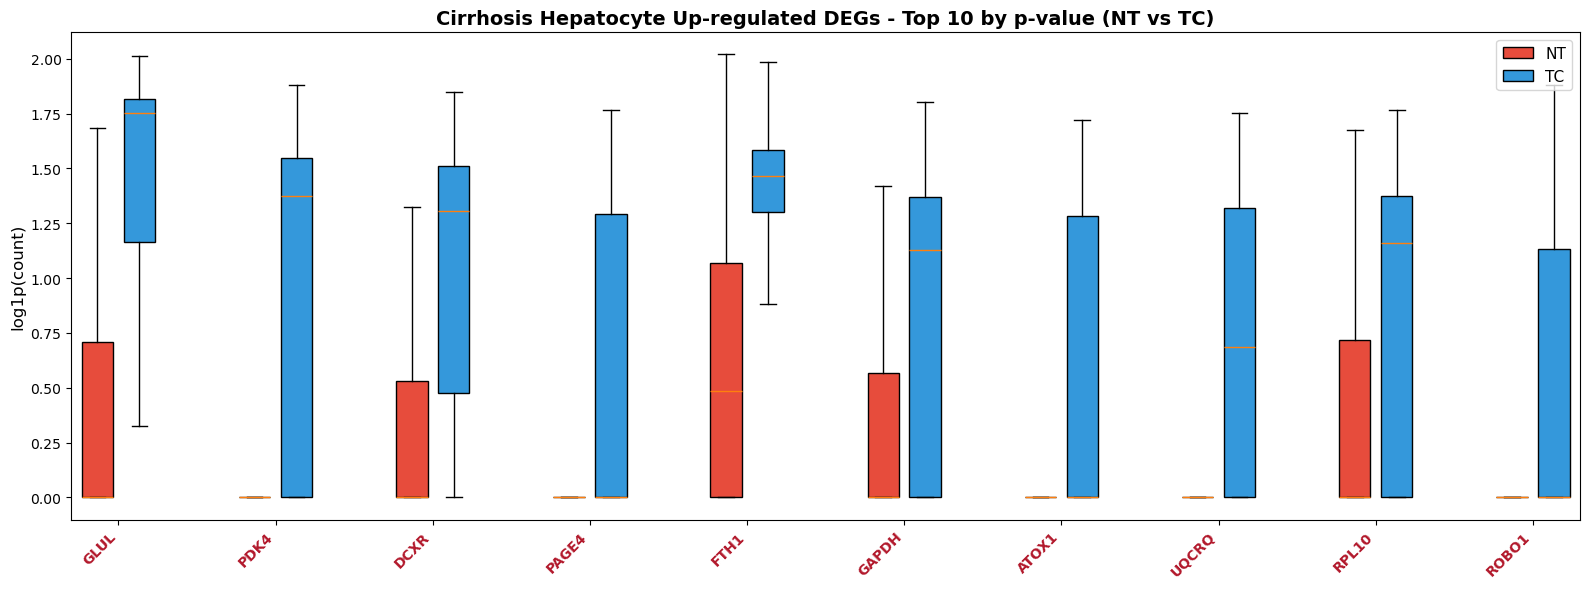

In [6]:
# Cirrhosis Boxplot: Up-regulated Top 10
up_genes = list(top_up['gene'])

fig, ax = plt.subplots(figsize=(16, 6))

nt_data = [expr_df.loc[expr_df['group'] == 'NT', g] for g in up_genes]
tc_data = [expr_df.loc[expr_df['group'] == 'TC', g] for g in up_genes]

pos_nt = np.arange(len(up_genes)) * 3
pos_tc = pos_nt + 0.8

bp_nt = ax.boxplot(nt_data, positions=pos_nt, widths=0.6, patch_artist=True, showfliers=False)
bp_tc = ax.boxplot(tc_data, positions=pos_tc, widths=0.6, patch_artist=True, showfliers=False)

for box in bp_nt['boxes']:
    box.set_facecolor('#E74C3C')
for box in bp_tc['boxes']:
    box.set_facecolor('#3498DB')

ax.set_xticks((pos_nt + pos_tc) / 2)
ax.set_xticklabels(up_genes, rotation=45, ha='right', fontsize=10, fontweight='bold')
for label in ax.get_xticklabels():
    label.set_color('#B2182B')

ax.set_ylabel('log1p(count)', fontsize=12)
ax.set_title('Cirrhosis Hepatocyte Up-regulated DEGs - Top 10 by p-value (NT vs TC)', fontsize=14, fontweight='bold')
ax.legend([bp_nt['boxes'][0], bp_tc['boxes'][0]], ['NT', 'TC'], loc='upper right', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'boxplot_Cirrhosis_Hepatocyte_Up.png'), dpi=300)
plt.show()

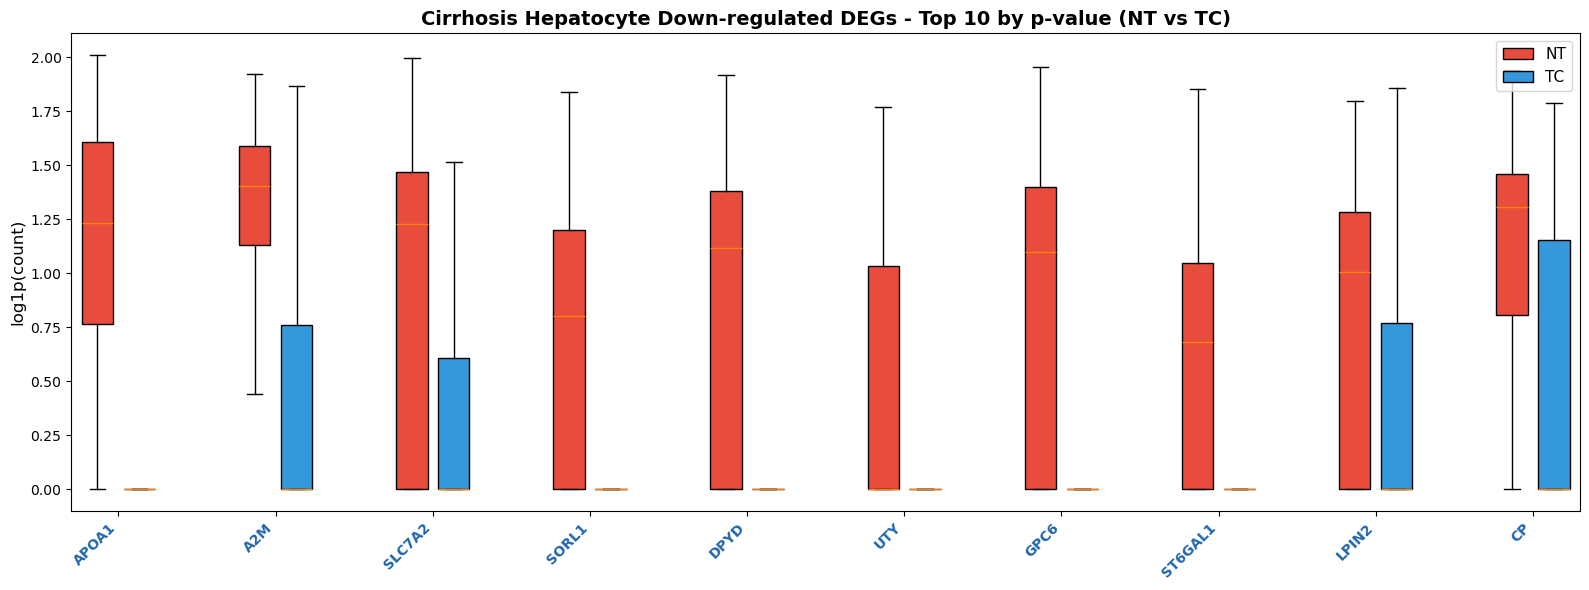

In [7]:
# Cirrhosis Boxplot: Down-regulated Top 10
down_genes = list(top_down['gene'])

fig, ax = plt.subplots(figsize=(16, 6))

nt_data = [expr_df.loc[expr_df['group'] == 'NT', g] for g in down_genes]
tc_data = [expr_df.loc[expr_df['group'] == 'TC', g] for g in down_genes]

pos_nt = np.arange(len(down_genes)) * 3
pos_tc = pos_nt + 0.8

bp_nt = ax.boxplot(nt_data, positions=pos_nt, widths=0.6, patch_artist=True, showfliers=False)
bp_tc = ax.boxplot(tc_data, positions=pos_tc, widths=0.6, patch_artist=True, showfliers=False)

for box in bp_nt['boxes']:
    box.set_facecolor('#E74C3C')
for box in bp_tc['boxes']:
    box.set_facecolor('#3498DB')

ax.set_xticks((pos_nt + pos_tc) / 2)
ax.set_xticklabels(down_genes, rotation=45, ha='right', fontsize=10, fontweight='bold')
for label in ax.get_xticklabels():
    label.set_color('#2166AC')

ax.set_ylabel('log1p(count)', fontsize=12)
ax.set_title('Cirrhosis Hepatocyte Down-regulated DEGs - Top 10 by p-value (NT vs TC)', fontsize=14, fontweight='bold')
ax.legend([bp_nt['boxes'][0], bp_tc['boxes'][0]], ['NT', 'TC'], loc='upper right', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'boxplot_Cirrhosis_Hepatocyte_Down.png'), dpi=300)
plt.show()

# log2fc 기준 sorting

In [8]:
# pvalue == 0 인 유전자만 추출 후 |log2FC| 기준 Top 10 (|log2FC| >= 0.5 이미 적용됨)
deg_pval0 = deg_sig[deg_sig['pvalue'] == 0].copy()

top_up_fc = deg_pval0[deg_pval0['log2FC'] > 0].nlargest(10, 'log2FC')
top_down_fc = deg_pval0[deg_pval0['log2FC'] < 0].nsmallest(10, 'log2FC')

print(f'pvalue==0 유전자 수: {len(deg_pval0)} (Up: {(deg_pval0["log2FC"]>0).sum()}, Down: {(deg_pval0["log2FC"]<0).sum()})')
print()
print('Top 10 Up (by log2FC):')
print(top_up_fc[['gene','log2FC','pvalue','padj']].to_string(index=False))
print()
print('Top 10 Down (by log2FC):')
print(top_down_fc[['gene','log2FC','pvalue','padj']].to_string(index=False))

pvalue==0 유전자 수: 339 (Up: 209, Down: 130)

Top 10 Up (by log2FC):
   gene    log2FC  pvalue  padj
  PAGE4 10.286291     0.0   0.0
  ROBO1  3.573873     0.0   0.0
ASPSCR1  3.381999     0.0   0.0
   PDK4  3.104279     0.0   0.0
  ATOX1  3.053994     0.0   0.0
   GLUL  2.912948     0.0   0.0
 NDUFA4  2.826320     0.0   0.0
   NME2  2.548555     0.0   0.0
 CHCHD2  2.541324     0.0   0.0
  UQCRQ  2.504237     0.0   0.0

Top 10 Down (by log2FC):
    gene    log2FC  pvalue  padj
   APOA1 -4.108160     0.0   0.0
   CCND3 -2.735396     0.0   0.0
     UTY -2.513844     0.0   0.0
ARHGAP26 -2.424163     0.0   0.0
     A2M -2.289167     0.0   0.0
   SORL1 -2.195745     0.0   0.0
    GPC6 -1.938668     0.0   0.0
   FOXO1 -1.924908     0.0   0.0
    PCCA -1.869545     0.0   0.0
 LDLRAD4 -1.833267     0.0   0.0


In [9]:
# pvalue==0 유전자 발현량 추출
target_genes_fc = list(top_up_fc['gene']) + list(top_down_fc['gene'])
gene_indices_fc = [gene_names.index(g) for g in target_genes_fc]

expr_raw_fc = counts[cell_idx][:, gene_indices_fc].toarray()
expr_log_fc = np.log1p(expr_raw_fc)

expr_df_fc = pd.DataFrame(expr_log_fc, columns=target_genes_fc)
expr_df_fc['group'] = groups

print(f'Expression matrix: {expr_df_fc.shape}')

Expression matrix: (55682, 21)


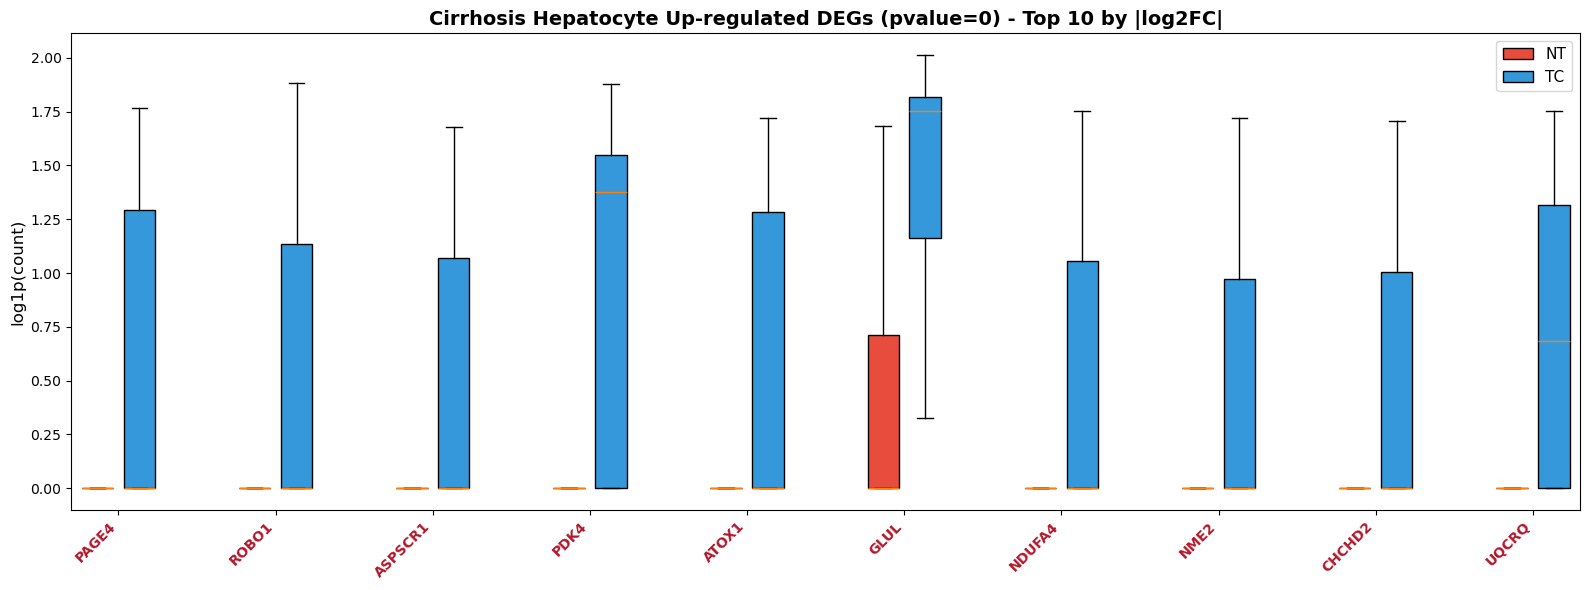

In [10]:
# Cirrhosis Boxplot: pvalue==0 Up Top 10 (by log2FC)
up_genes_fc = list(top_up_fc['gene'])

fig, ax = plt.subplots(figsize=(16, 6))

nt_data = [expr_df_fc.loc[expr_df_fc['group'] == 'NT', g] for g in up_genes_fc]
tc_data = [expr_df_fc.loc[expr_df_fc['group'] == 'TC', g] for g in up_genes_fc]

pos_nt = np.arange(len(up_genes_fc)) * 3
pos_tc = pos_nt + 0.8

bp_nt = ax.boxplot(nt_data, positions=pos_nt, widths=0.6, patch_artist=True, showfliers=False)
bp_tc = ax.boxplot(tc_data, positions=pos_tc, widths=0.6, patch_artist=True, showfliers=False)

for box in bp_nt['boxes']:
    box.set_facecolor('#E74C3C')
for box in bp_tc['boxes']:
    box.set_facecolor('#3498DB')

ax.set_xticks((pos_nt + pos_tc) / 2)
ax.set_xticklabels(up_genes_fc, rotation=45, ha='right', fontsize=10, fontweight='bold')
for label in ax.get_xticklabels():
    label.set_color('#B2182B')

ax.set_ylabel('log1p(count)', fontsize=12)
ax.set_title('Cirrhosis Hepatocyte Up-regulated DEGs (pvalue=0) - Top 10 by |log2FC|', fontsize=14, fontweight='bold')
ax.legend([bp_nt['boxes'][0], bp_tc['boxes'][0]], ['NT', 'TC'], loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

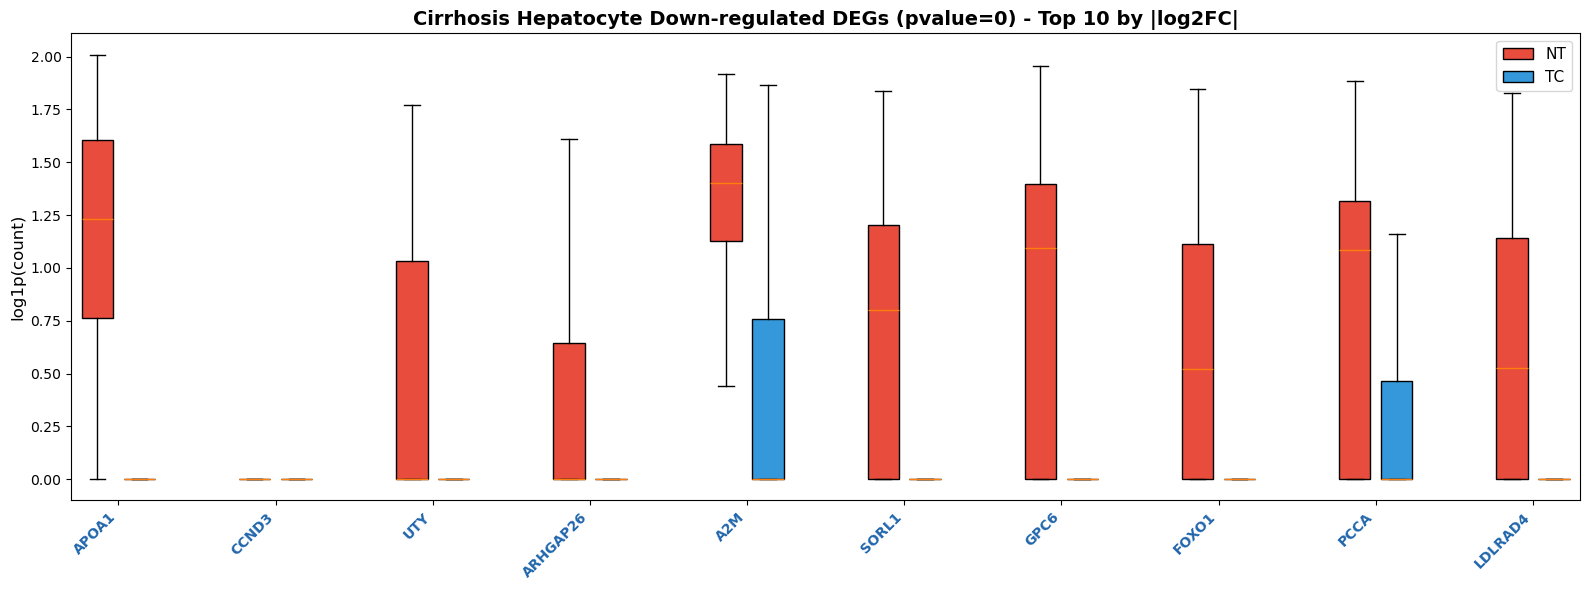

In [11]:
# Cirrhosis Boxplot: pvalue==0 Down Top 10 (by |log2FC|)
down_genes_fc = list(top_down_fc['gene'])

fig, ax = plt.subplots(figsize=(16, 6))

nt_data = [expr_df_fc.loc[expr_df_fc['group'] == 'NT', g] for g in down_genes_fc]
tc_data = [expr_df_fc.loc[expr_df_fc['group'] == 'TC', g] for g in down_genes_fc]

pos_nt = np.arange(len(down_genes_fc)) * 3
pos_tc = pos_nt + 0.8

bp_nt = ax.boxplot(nt_data, positions=pos_nt, widths=0.6, patch_artist=True, showfliers=False)
bp_tc = ax.boxplot(tc_data, positions=pos_tc, widths=0.6, patch_artist=True, showfliers=False)

for box in bp_nt['boxes']:
    box.set_facecolor('#E74C3C')
for box in bp_tc['boxes']:
    box.set_facecolor('#3498DB')

ax.set_xticks((pos_nt + pos_tc) / 2)
ax.set_xticklabels(down_genes_fc, rotation=45, ha='right', fontsize=10, fontweight='bold')
for label in ax.get_xticklabels():
    label.set_color('#2166AC')

ax.set_ylabel('log1p(count)', fontsize=12)
ax.set_title('Cirrhosis Hepatocyte Down-regulated DEGs (pvalue=0) - Top 10 by |log2FC|', fontsize=14, fontweight='bold')
ax.legend([bp_nt['boxes'][0], bp_tc['boxes'][0]], ['NT', 'TC'], loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

# 평균 발현량이 많은 sorting

In [12]:
# pvalue==0 유전자들의 평균 발현량 계산 후 Top 10 Up/Down 선택
deg_pval0_genes = list(deg_pval0['gene'])
deg_pval0_indices = [gene_names.index(g) for g in deg_pval0_genes]

# 전체 Cirrhosis Hepatocyte에서 평균 발현량 계산
expr_pval0_raw = counts[cell_idx][:, deg_pval0_indices].toarray()
expr_pval0_log = np.log1p(expr_pval0_raw)
mean_expr = pd.Series(expr_pval0_log.mean(axis=0), index=deg_pval0_genes)

deg_pval0['mean_expr'] = deg_pval0['gene'].map(mean_expr).values

top_up_mean = deg_pval0[deg_pval0['log2FC'] > 0].nlargest(10, 'mean_expr')
top_down_mean = deg_pval0[deg_pval0['log2FC'] < 0].nlargest(10, 'mean_expr')

print('Top 10 Up (by mean expression):')
print(top_up_mean[['gene','log2FC','mean_expr','pvalue','padj']].to_string(index=False))
print()
print('Top 10 Down (by mean expression):')
print(top_down_mean[['gene','log2FC','mean_expr','pvalue','padj']].to_string(index=False))

# 발현량 추출
target_genes_mean = list(top_up_mean['gene']) + list(top_down_mean['gene'])
gene_indices_mean = [gene_names.index(g) for g in target_genes_mean]

expr_raw_mean = counts[cell_idx][:, gene_indices_mean].toarray()
expr_log_mean = np.log1p(expr_raw_mean)

expr_df_mean = pd.DataFrame(expr_log_mean, columns=target_genes_mean)
expr_df_mean['group'] = groups

print(f'\nExpression matrix: {expr_df_mean.shape}')

Top 10 Up (by mean expression):
  gene   log2FC  mean_expr  pvalue  padj
 APOA2 0.864695   1.671691     0.0   0.0
  RBP4 0.764792   1.523297     0.0   0.0
 APOC3 0.616094   1.498083     0.0   0.0
  CPS1 0.927538   1.487330     0.0   0.0
   FTL 0.841277   1.482136     0.0   0.0
 APOC1 0.566500   1.439601     0.0   0.0
MT-ND5 0.541653   1.434460     0.0   0.0
MT-CO2 0.675626   1.422211     0.0   0.0
  APOE 0.754814   1.419282     0.0   0.0
MT-CYB 0.721850   1.361796     0.0   0.0

Top 10 Down (by mean expression):
  gene    log2FC  mean_expr  pvalue  padj
   PLG -0.564969   0.736587     0.0   0.0
CYP2C9 -0.709322   0.582761     0.0   0.0
ERRFI1 -0.780826   0.582272     0.0   0.0
    CP -1.246939   0.567099     0.0   0.0
   LPP -0.897706   0.524588     0.0   0.0
CYP3A5 -1.676945   0.510574     0.0   0.0
  NFIA -0.778928   0.501887     0.0   0.0
 ITIH4 -1.087647   0.492403     0.0   0.0
   DST -0.989018   0.477240     0.0   0.0
FNDC3B -1.042613   0.463743     0.0   0.0

Expression matrix: 

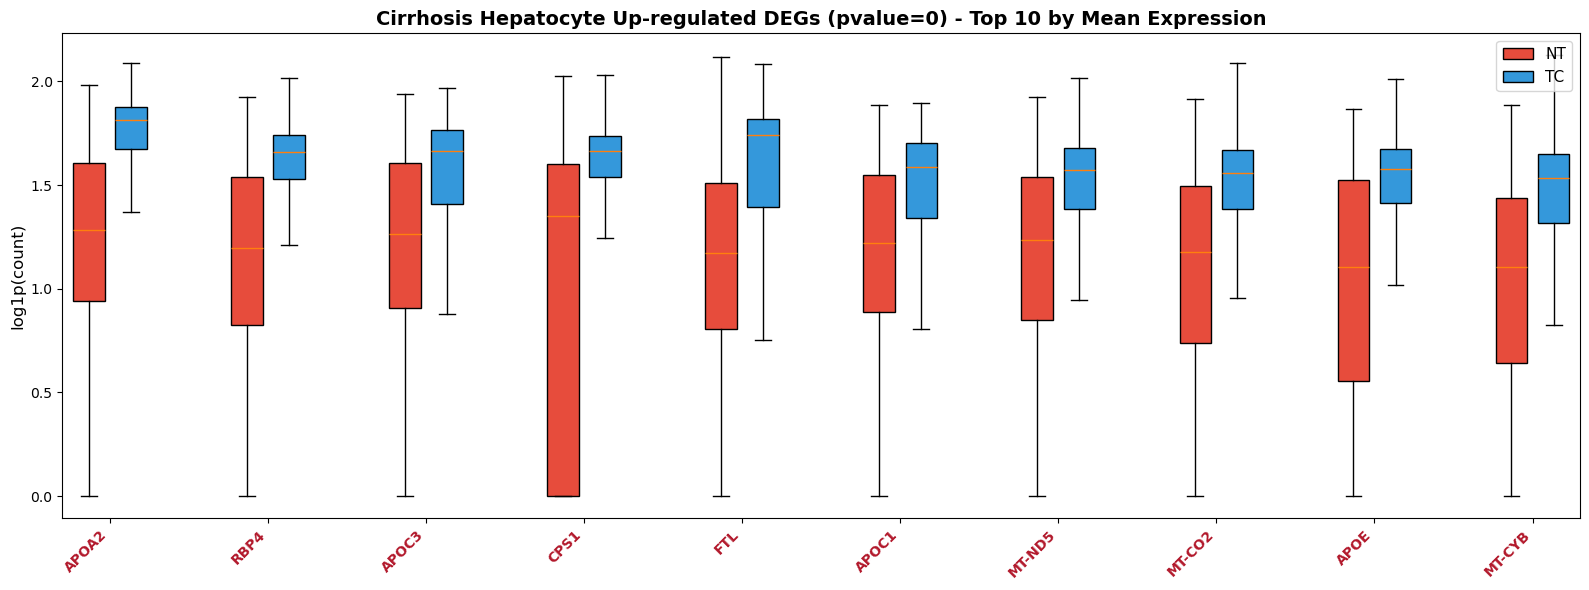

In [13]:
# Cirrhosis Boxplot: pvalue==0 Up Top 10 (by mean expression)
up_genes_mean = list(top_up_mean['gene'])

fig, ax = plt.subplots(figsize=(16, 6))

nt_data = [expr_df_mean.loc[expr_df_mean['group'] == 'NT', g] for g in up_genes_mean]
tc_data = [expr_df_mean.loc[expr_df_mean['group'] == 'TC', g] for g in up_genes_mean]

pos_nt = np.arange(len(up_genes_mean)) * 3
pos_tc = pos_nt + 0.8

bp_nt = ax.boxplot(nt_data, positions=pos_nt, widths=0.6, patch_artist=True, showfliers=False)
bp_tc = ax.boxplot(tc_data, positions=pos_tc, widths=0.6, patch_artist=True, showfliers=False)

for box in bp_nt['boxes']:
    box.set_facecolor('#E74C3C')
for box in bp_tc['boxes']:
    box.set_facecolor('#3498DB')

ax.set_xticks((pos_nt + pos_tc) / 2)
ax.set_xticklabels(up_genes_mean, rotation=45, ha='right', fontsize=10, fontweight='bold')
for label in ax.get_xticklabels():
    label.set_color('#B2182B')

ax.set_ylabel('log1p(count)', fontsize=12)
ax.set_title('Cirrhosis Hepatocyte Up-regulated DEGs (pvalue=0) - Top 10 by Mean Expression', fontsize=14, fontweight='bold')
ax.legend([bp_nt['boxes'][0], bp_tc['boxes'][0]], ['NT', 'TC'], loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

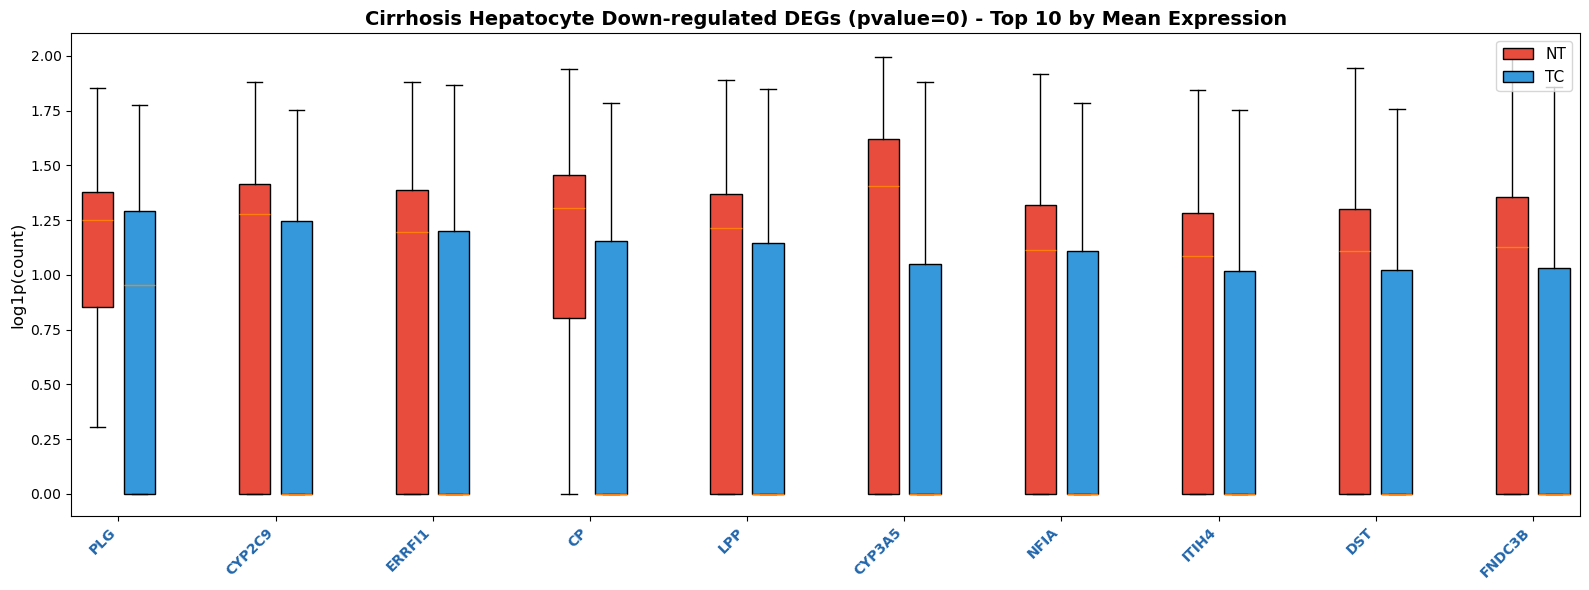

In [14]:
# Cirrhosis Boxplot: pvalue==0 Down Top 10 (by mean expression)
down_genes_mean = list(top_down_mean['gene'])

fig, ax = plt.subplots(figsize=(16, 6))

nt_data = [expr_df_mean.loc[expr_df_mean['group'] == 'NT', g] for g in down_genes_mean]
tc_data = [expr_df_mean.loc[expr_df_mean['group'] == 'TC', g] for g in down_genes_mean]

pos_nt = np.arange(len(down_genes_mean)) * 3
pos_tc = pos_nt + 0.8

bp_nt = ax.boxplot(nt_data, positions=pos_nt, widths=0.6, patch_artist=True, showfliers=False)
bp_tc = ax.boxplot(tc_data, positions=pos_tc, widths=0.6, patch_artist=True, showfliers=False)

for box in bp_nt['boxes']:
    box.set_facecolor('#E74C3C')
for box in bp_tc['boxes']:
    box.set_facecolor('#3498DB')

ax.set_xticks((pos_nt + pos_tc) / 2)
ax.set_xticklabels(down_genes_mean, rotation=45, ha='right', fontsize=10, fontweight='bold')
for label in ax.get_xticklabels():
    label.set_color('#2166AC')

ax.set_ylabel('log1p(count)', fontsize=12)
ax.set_title('Cirrhosis Hepatocyte Down-regulated DEGs (pvalue=0) - Top 10 by Mean Expression', fontsize=14, fontweight='bold')
ax.legend([bp_nt['boxes'][0], bp_tc['boxes'][0]], ['NT', 'TC'], loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()